In [54]:
## This notebook is interested in famous dataset on heart disease, which is available in the UCI Machine Learning Repository. 
# 
# The dataset contains 303 instances and 14 attributes, including   - age
# - sex
# - chest pain type (4 values)  
# - resting blood pressure
# - serum cholestoral in mg/dl
# - fasting blood sugar > 120 mg/dl
# - resting electrocardiographic results (values 0,1,2)
# - maximum heart rate achieved
# - exercise induced angina
# - oldpeak = ST depression induced by exercise relative to rest
# - the slope of the peak exercise ST segment
# - number of major vessels (0-3) colored by flourosopy
# - thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
# - target: 0= less chance of heart attack, 1= more chance of heart attack
# The dataset is available at https://archive.ics.uci.edu/ml/datasets/heart+Disease
# We will use the dataset to predict the target variable, which indicates the likelihood of heart disease.
# First, we will load the dataset and perform some exploratory data analysis to understand the distribution of the features and the target variable. Then, we will preprocess the data, handle any missing values, and encode categorical variables if necessary. Finally, we will build a machine learning model to predict the target variable and evaluate its performance using appropriate metrics.


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target",
]
df = pd.read_csv(url, names=column_names)
# Display the first few rows of the dataset
print(df.head()) 
# Check for missing values
print(df.isnull().sum())

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0  3.0       0  
4    1.0  0.0  3.0       0  
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [56]:
# Seems like we do not have any missing values. Probably somebody did our job and prepared the dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [57]:
df["ca"].value_counts()

ca
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: count, dtype: int64

In [58]:
df["ca"] = df["ca"].replace("?", np.nan)
df["thal"] = df["thal"].replace("?", np.nan)

In [59]:
df["ca"].value_counts()

ca
0.0    176
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64

In [60]:
df["ca"] = pd.to_numeric(df["ca"])
df["thal"] = pd.to_numeric(df["thal"])


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [62]:
## We convert string valeus to float which we need
## Now we will fill the null values with the median of that feature
df["ca"] = df["ca"].fillna(df["ca"].median())
df["thal"] = df["thal"].fillna(df["thal"].median())

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


Now all data types are float and there is no null values
Now lets look the outliers

In [64]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


Seems like there are no outlier instances

Now we will remove duplicates and encode the categorical values

In [65]:
df.drop_duplicates()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


There is no categorical feature in this dataset

Now we must apply feature scaling

In [66]:
column_names = df.columns
column_names

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_array = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled_array, columns=column_names, index=df.index)


Now we adjust target values to 0 and 1


In [67]:
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
df.head(20)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [68]:
type(df)

pandas.DataFrame

In [69]:
X = df.drop("target", axis=1)
y = df["target"]

In [70]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X)

StandardScaler()

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


We split our dataset into train and test sets
Also we seperated the target values

Now we must select a model and evaluate

Lets choose RandomForestClassifier

In [72]:
from sklearn.ensemble import RandomForestClassifier

model_randomForest = RandomForestClassifier()
model_randomForest.fit(X_train, y_train) 

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Lets evaluate our model

In [73]:
y_pred = model_randomForest.predict(X_test)
from sklearn.metrics import accuracy_score
print(f"Random Forest Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Random Forest Model Accuracy: 90.16%


Lets Choose another model

In [74]:
import xgboost as xgb
model_XG = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, use_label_encoder=False, eval_metric='logloss')
model_XG.fit(X_train, y_train)
y_pred = model_XG.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred):.4f}")

XGBoost Accuracy: 0.8361


c:\Users\furka\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:12:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


One last model as logistic regression

In [75]:
from sklearn.linear_model import LogisticRegression

model_logisticReg = LogisticRegression(max_iter=1000)
model_logisticReg.fit(X_train, y_train)
y_pred = model_logisticReg.predict(X_test)

print(f"Logistic Regression Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Logistic Regression Model Accuracy: 0.8852


Seems like Logistic Regression is the best model for this data set.

But we did not create models with different parameter maybe there is a random forest classifier with certain parameters that performs better than the other.

How can we know

We can try different parameter sets for each model and keep the best model.

Luckily sciki-learn has a library for this job.

We can use GridSearchCV or RandomizedSearchCV in scikit-learn or we can use more prossional tool like optuna which uses bayesian optimziation. But since our dataset is small and this isnt a professional project and our accracy almost 90 percent we must choose logistic regression(highest accuracy)

One last thing: we must check if our model underfits or overfits

To check whether our model overfits, we must compute the accuracy on the train set. If accuracy on the train set is almost 100 percent it means model memorizes the data which called overfitting.

In [76]:
y_predCheck = model_logisticReg.predict(X_train)
print(f"Logistic Regression Model Accuracy on the train set: {accuracy_score(y_train, y_predCheck):.4f}")

Logistic Regression Model Accuracy on the train set: 0.8430


That means our Logistic Regressor learns the patterns in the data not just memorizes the data

We finished our project.

Now we will find out which features effects the heart disease probability the most.



In [77]:


# Katsayıları bir DataFrame'e dök
importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': model_logisticReg.coef_[0]})

# Katsayıların mutlak değerini al (çünkü negatif etki de önemlidir)
importance['abs_val'] = importance['Coefficient'].abs()

# En yüksek etkiye sahip olanları sırala
importance = importance.sort_values(by='abs_val', ascending=False)
print(importance)

     Feature  Coefficient   abs_val
1        sex     1.236026  1.236026
11        ca     1.224896  1.224896
8      exang     0.792270  0.792270
10     slope     0.596271  0.596271
5        fbs    -0.581419  0.581419
2         cp     0.504860  0.504860
9    oldpeak     0.323599  0.323599
12      thal     0.274737  0.274737
6    restecg     0.147289  0.147289
3   trestbps     0.017199  0.017199
7    thalach    -0.014158  0.014158
4       chol     0.008531  0.008531
0        age     0.003834  0.003834


We determined how much each feature effects the target value (heart disease probablity).

Looks like sex and ca features are the most effective in heart disease.

Now lets visualize that

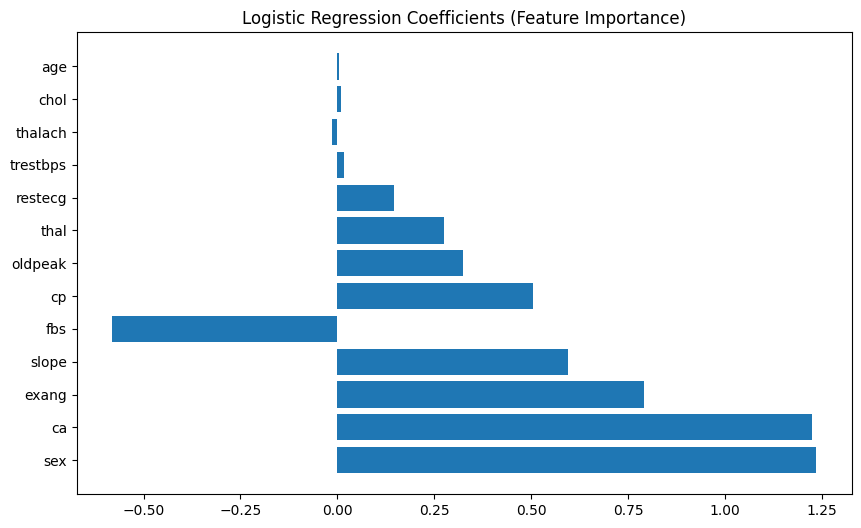

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(importance['Feature'], importance['Coefficient'])
plt.title('Logistic Regression Coefficients (Feature Importance)')
plt.show()

Now we will export and stream our model.

In [79]:
import joblib

# Modelini ve scaler'ını kaydet
joblib.dump(model_logisticReg, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [80]:
print(list(X_train.columns))

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


END OF THE PROJECT